<a href="https://colab.research.google.com/github/ujju2020/Generating_Fake_Images_With_GANs/blob/main/Generating_Fake_Images_With_GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten
from tensorflow.keras.models import Sequential
import numpy as np

In [2]:
# Load MNIST data
(X_train, _), (_, _) = mnist.load_data()
# Normalize to between -1 and 1
X_train = (X_train.astype(np.float32) - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=3)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Generator
def create_generator():
    model = Sequential()
    model.add(Dense(256, input_dim=100, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(1024, activation='relu'))
    model.add(Dense(784, activation='tanh'))
    model.add(Reshape((28, 28, 1)))
    return model

# Discriminator
def create_discriminator():
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(1024, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

In [4]:
from tensorflow.keras.models import Sequential, Model

# Create and compile the discriminator
discriminator = create_discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer='adam')

# Create and compile the generator
generator = create_generator()
generator.compile(loss='binary_crossentropy', optimizer='adam')

# Create and compile the combined model
discriminator.trainable = False
gan_input = Input(shape=(100,))
x = generator(gan_input)
gan_output = discriminator(x)
gan = Model(inputs=gan_input, outputs=gan_output)
gan.compile(loss='binary_crossentropy', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
def train(epochs=1, batch_size=128):
    # Load the data
    (X_train, _), (_, _) = mnist.load_data()
    X_train = (X_train.astype(np.float32) - 127.5) / 127.5
    X_train = np.expand_dims(X_train, axis=3)

    # Labels for the batch size and the test size
    y_train_ones = np.ones((batch_size, 1))
    y_train_zeros = np.zeros((batch_size, 1))
    y_test_ones = np.ones((100, 1))

    # Start training
    for e in range(epochs):
        for i in range(X_train.shape[0] // batch_size):
            # Train Discriminator weights
            discriminator.trainable = True

            # Real samples
            X_batch = X_train[i*batch_size:(i+1)*batch_size]
            d_loss_real = discriminator.train_on_batch(x=X_batch, y=y_train_ones * (1 - 0.1 * np.random.rand(batch_size, 1)))

            # Fake Samples
            z_noise = np.random.normal(loc=0, scale=1, size=(batch_size, 100))
            X_fake = generator.predict_on_batch(z_noise)
            d_loss_fake = discriminator.train_on_batch(x=X_fake, y=y_train_zeros)

            # Discriminator loss
            d_loss = 0.5 * (d_loss_real + d_loss_fake)

            # Train Generator weights
            discriminator.trainable = False
            g_loss = gan.train_on_batch(x=z_noise, y=y_train_ones)

            print(f'Epoch: {e+1}, Batch: {i}, D Loss: {d_loss}, G Loss: {g_loss}')

In [6]:
# Call the train function
train(epochs=50, batch_size=128)

Streaming output truncated to the last 5000 lines.
Epoch: 40, Batch: 148, D Loss: 0.10708344727754593, G Loss: 17.551116943359375
Epoch: 40, Batch: 149, D Loss: 0.1070832759141922, G Loss: 17.551504135131836
Epoch: 40, Batch: 150, D Loss: 0.10708321630954742, G Loss: 17.55191993713379
Epoch: 40, Batch: 151, D Loss: 0.10708282887935638, G Loss: 17.552345275878906
Epoch: 40, Batch: 152, D Loss: 0.10708238929510117, G Loss: 17.552759170532227
Epoch: 40, Batch: 153, D Loss: 0.1070820614695549, G Loss: 17.553157806396484
Epoch: 40, Batch: 154, D Loss: 0.10708145797252655, G Loss: 17.55352783203125
Epoch: 40, Batch: 155, D Loss: 0.10708138346672058, G Loss: 17.55390167236328
Epoch: 40, Batch: 156, D Loss: 0.10708043724298477, G Loss: 17.554262161254883
Epoch: 40, Batch: 157, D Loss: 0.1070803701877594, G Loss: 17.554641723632812
Epoch: 40, Batch: 158, D Loss: 0.10707974433898926, G Loss: 17.555034637451172
Epoch: 40, Batch: 159, D Loss: 0.10707929730415344, G Loss: 17.555435180664062
Epoch: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


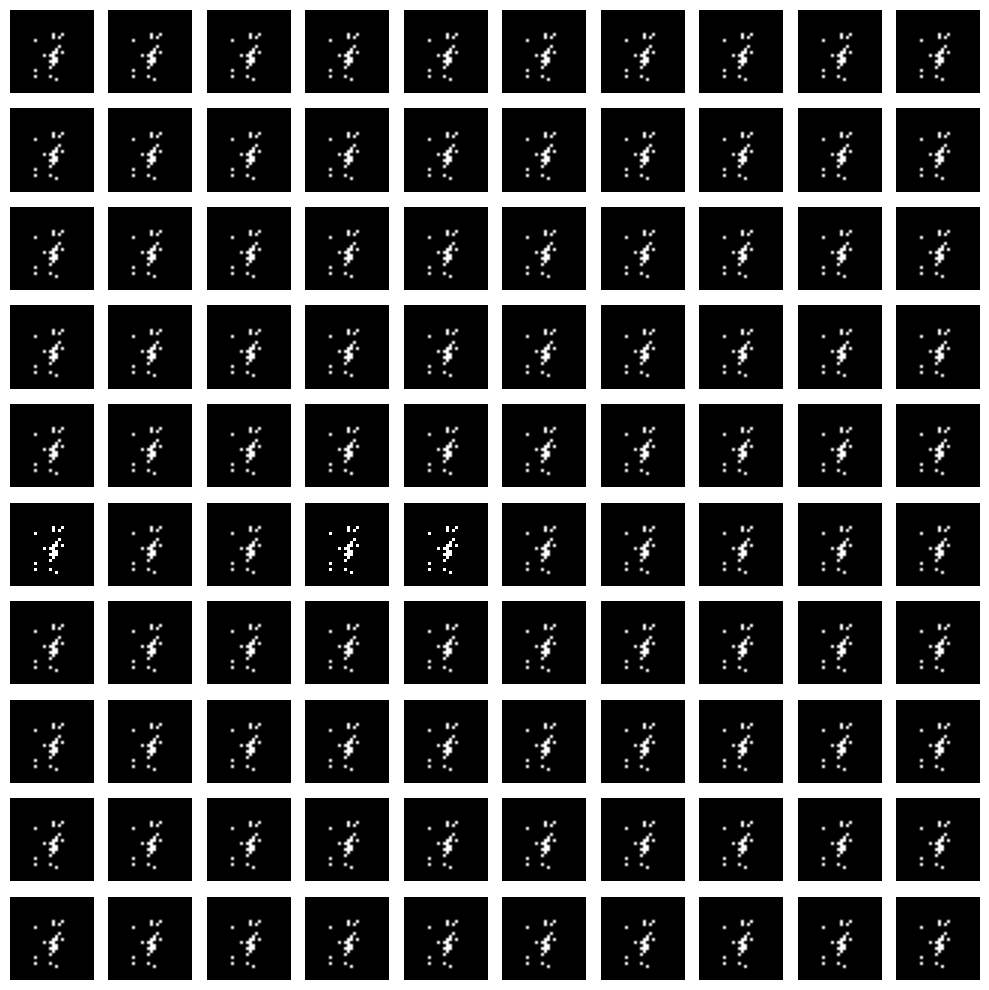

In [7]:
import matplotlib.pyplot as plt
# Generate random noise as an input to initialize the generator
random_noise = np.random.normal(0,1, [100, 100])

# Generate the images from the noise
generated_images = generator.predict(random_noise)

# Visualize the generated images
plt.figure(figsize=(10,10))
for i in range(generated_images.shape[0]):
    plt.subplot(10, 10, i+1)
    plt.imshow(generated_images[i, :, :, 0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()